# Curate the FP dataset, split, and visualize the splits

End-to-end:
1. **Flag outliers** on the original 894-sample dataset by: (1) non-empty FPbase `cofactor`, (2) nearest-neighbor
   4-mer similarity < 0.10, and (3) an explicit name flag for **frFAST / nirFAST** (fluorogen-activating; missed by
   both other rules).
2. **Visualize** NN-similarity and the ESM-2 embedding of the *full* dataset with the outliers highlighted.
3. **Curate** = drop the flagged rows; write the curated dataset in `build_peak_dataset.py` format.
4. **Split** into coordinated surrogate + oracle train/val/test (same logic as the dual notebook, seed 0, 70/15/15).
5. **Visualize the curated dataset** — ESM-2 embedding (t-SNE), ex_max, em_max, and length — coloring train/val/test
   separately, for **both** the surrogate and oracle splits.

(*"em_max/em_min"* is read as the two peak targets **ex_max & em_max** — there is no em_min in the data.)
Nothing destructive: curated artifacts go under `training_data/curated/`.

## 0. Load original dataset + flag outliers

In [1]:
import csv, json, os, numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cossim
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception: HAVE_APC=False
import matplotlib.pyplot as plt
class _C:
    def __getattr__(self,k): return getattr(apc,k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#9a9a9a","dragon":"#b23b3b","aster":"#7a5ea8"}.get(k,"#333")
C=_C()
TD="training_data"
rows=list(csv.DictReader(open(f"{TD}/peak_assignments.csv"))); N=len(rows)
peaks=np.load(f"{TD}/peaks.npy").astype(np.float32); EX=peaks[:,0]; EM=peaks[:,1]
names=[r["name"] for r in rows]; slug=[r["slug"] for r in rows]; LEN=np.array([int(r["seq_len"]) for r in rows])
seqs=[None]*N; h=None
for line in open(f"{TD}/sequences.fasta"):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
prot=json.load(open("../fpbase-extractor/fpbase_output/fpbase_proteins.json"))
cofmap={p["slug"]:(p.get("cofactor") or "") for p in prot}
COF=np.array([cofmap.get(s,"") for s in slug])
Hh=np.load(f"{TD}/esm_residue_fp16.npy"); Ls=np.load(f"{TD}/esm_residue_len.npy")
emb=np.stack([Hh[i,:Ls[i]].astype(np.float32).mean(0) for i in range(N)])    # mean-pooled ESM-2

# (1) cofactor  (2) NN 4-mer similarity < 0.10  (3) explicit frFAST/nirFAST
f_cof=np.array([c.strip().lower() not in ("","none") for c in COF])
Xk=CountVectorizer(analyzer="char",ngram_range=(4,4)).fit_transform(seqs)
Sk=cossim(Xk); np.fill_diagonal(Sk,-1); NN=Sk.max(1)
f_nn=NN<0.10
f_fast=np.array([("nirfast" in n.lower() or "frfast" in n.lower()) for n in names])
OUT=f_cof|f_nn|f_fast
print(f"N={N} | outliers={OUT.sum()}  (cofactor {f_cof.sum()}, NN<0.10 {f_nn.sum()}, frFAST/nirFAST {f_fast.sum()})")
print(f"  overlap: cofactor&NN {(f_cof&f_nn).sum()} | unique-to-NN {(f_nn&~f_cof&~f_fast).sum()} | unique-to-FAST {(f_fast&~f_cof&~f_nn).sum()}")
print("frFAST/nirFAST rows:", [names[i] for i in np.where(f_fast)[0]])

N=823 | outliers=65  (cofactor 59, NN<0.10 8, frFAST/nirFAST 2)
  overlap: cofactor&NN 4 | unique-to-NN 4 | unique-to-FAST 2
frFAST/nirFAST rows: ['frFAST', 'nirFAST  + HPAR-3,5DOM']


## 1. Visualize NN similarity + ESM-2 embedding (full dataset, outliers flagged)

Left: distribution of nearest-neighbor 4-mer similarity with the 0.10 threshold. Right: 2-D t-SNE of the
mean-pooled ESM-2 embeddings; kept samples in light gray, outliers overlaid by reason (cofactor / NN-isolated /
frFAST-nirFAST). A point can carry more than one marker.

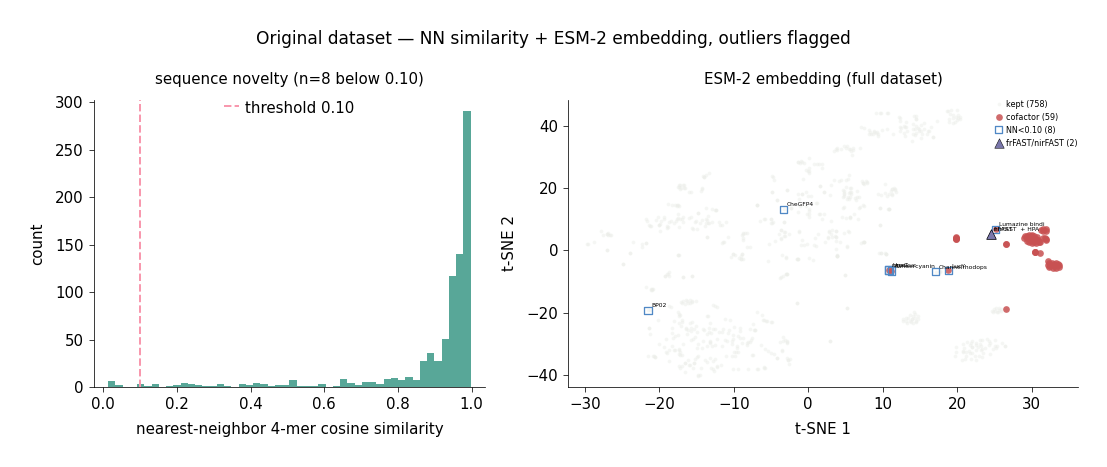

In [2]:
TS=TSNE(2,random_state=0,perplexity=30,init="pca").fit_transform(
        PCA(50,random_state=0).fit_transform((emb-emb.mean(0))/(emb.std(0)+1e-6)))
fig,ax=plt.subplots(1,2,figsize=(15,6),gridspec_kw={"width_ratios":[1,1.3]})
ax[0].hist(NN,bins=50,color=C.seaweed,alpha=0.85); ax[0].axvline(0.10,color=C.rose,ls="--",label="threshold 0.10")
ax[0].set_xlabel("nearest-neighbor 4-mer cosine similarity"); ax[0].set_ylabel("count")
ax[0].set_title(f"sequence novelty (n={int(f_nn.sum())} below 0.10)"); ax[0].legend()
ax[1].scatter(TS[:,0],TS[:,1],s=14,c=C.gray,alpha=0.45,label=f"kept ({(~OUT).sum()})")
ax[1].scatter(TS[f_cof,0],TS[f_cof,1],s=45,c=C.dragon,alpha=0.85,label=f"cofactor ({f_cof.sum()})")
ax[1].scatter(TS[f_nn,0], TS[f_nn,1], s=55,marker="s",facecolors="none",edgecolors=C.aegean,lw=1.3,label=f"NN<0.10 ({f_nn.sum()})")
ax[1].scatter(TS[f_fast,0],TS[f_fast,1],s=90,marker="^",c=C.aster,edgecolors="k",lw=0.5,label=f"frFAST/nirFAST ({f_fast.sum()})")
for i in np.where(f_fast|f_nn)[0]: ax[1].annotate(names[i][:14],(TS[i,0],TS[i,1]),fontsize=6,xytext=(3,3),textcoords="offset points")
ax[1].set_xlabel("t-SNE 1"); ax[1].set_ylabel("t-SNE 2"); ax[1].set_title("ESM-2 embedding (full dataset)"); ax[1].legend(fontsize=8)
plt.suptitle("Original dataset — NN similarity + ESM-2 embedding, outliers flagged"); plt.tight_layout(); plt.show()

## 2. Create the curated dataset (drop flagged outliers)

In [3]:
keep=np.where(~OUT)[0]; Nc=len(keep)
cur=f"{TD}/curated"; os.makedirs(cur,exist_ok=True)
np.save(f"{cur}/keep_index.npy", keep)
np.save(f"{cur}/peaks.npy", peaks[keep])
with open(f"{cur}/sequences.fasta","w") as fh:
    for newi,oldi in enumerate(keep): fh.write(f">{newi}|{slug[oldi]}\n{seqs[oldi]}\n")
cols=list(rows[0].keys())+["orig_index"]
with open(f"{cur}/peak_assignments.csv","w",newline="") as fh:
    w=csv.DictWriter(fh,fieldnames=cols); w.writeheader()
    for newi,oldi in enumerate(keep):
        r=dict(rows[oldi]); r["orig_index"]=oldi; r["index"]=newi; w.writerow(r)
reasons={"cofactor":int(f_cof.sum()),"NN<0.10":int(f_nn.sum()),"frFAST/nirFAST":int(f_fast.sum()),
         "total_dropped":int(OUT.sum()),"kept":int(Nc),"original":int(N)}
json.dump({"filter":"cofactor | NN4mer<0.10 | name~(frFAST|nirFAST)","counts":reasons,
           "dropped_names":[names[i] for i in np.where(OUT)[0]]}, open(f"{cur}/curate_meta.json","w"), indent=2)
print(f"curated: kept {Nc} / {N}  (dropped {OUT.sum()}) -> {cur}/")
print("dropped breakdown:", reasons)

curated: kept 758 / 823  (dropped 65) -> training_data/curated/
dropped breakdown: {'cofactor': 59, 'NN<0.10': 8, 'frFAST/nirFAST': 2, 'total_dropped': 65, 'kept': 758, 'original': 823}


## 3. Train/val/test split — coordinated surrogate + oracle

Same logic as `surrogate_oracle_peak_dual.ipynb` (seed 0, 70/15/15), applied to the **curated** rows: two
coordinated splits with disjoint val sets, `S_test ⊆ O_train`, `O_test ⊆ S_train`.

In [4]:
curows=list(csv.DictReader(open(f"{cur}/peak_assignments.csv")))
EXc=np.load(f"{cur}/peaks.npy")[:,0]; EMc=np.load(f"{cur}/peaks.npy")[:,1]
LENc=np.array([int(r["seq_len"]) for r in curows]); cnames=[r["name"] for r in curows]
embc=emb[keep]
SEED=0; perm=np.random.default_rng(SEED).permutation(Nc); n_te=int(round(.15*Nc)); n_va=int(round(.15*Nc))
Srole=np.array(["train"]*Nc); Srole[perm[:n_te]]="test"; Srole[perm[n_te:n_te+n_va]]="val"
s_train=perm[n_te+n_va:]; st=np.random.default_rng(SEED+1).permutation(s_train)
Orole=np.array(["train"]*Nc); Orole[st[:n_te]]="test"; Orole[st[n_te:n_te+n_va]]="val"
assert np.all(Orole[Srole=="test"]=="train") and np.all(Srole[Orole=="test"]=="train")
with open(f"{cur}/dual_splits.csv","w",newline="") as fh:
    w=csv.writer(fh); w.writerow(["index","name","surrogate_role","oracle_role"])
    for i in range(Nc): w.writerow([i,cnames[i],Srole[i],Orole[i]])
def cnt(a): return {b:int((a==b).sum()) for b in ("train","val","test")}
print(f"curated N={Nc}")
print("surrogate split:", cnt(Srole)); print("oracle    split:", cnt(Orole))
# shared t-SNE layout for the curated set (same coords; only the coloring differs per split)
TSc=TSNE(2,random_state=0,perplexity=30,init="pca").fit_transform(
        PCA(50,random_state=0).fit_transform((embc-embc.mean(0))/(embc.std(0)+1e-6)))
ROLECOL={"train":C.gray,"val":C.aegean,"test":C.amber}

curated N=758
surrogate split: {'train': 530, 'val': 114, 'test': 114}
oracle    split: {'train': 530, 'val': 114, 'test': 114}


## 3b. Dual-split bipartite map

How the surrogate roles map onto the oracle roles: node size ∝ #FPs in that role; edge width/label ∝ #FPs
shared between a surrogate role and an oracle role. By construction `S_test ⊆ O_train` and `O_test ⊆ S_train`
with disjoint val sets — so each side's test set is fully seen during the other's training (the basis for the
in-sample vs OOD design evaluation in `surrogate_oracle_peak_dual.ipynb`).

surrogate-role -> oracle-role contingency:
  S_train -> O_train 302, O_val 114, O_test 114
  S_val   -> O_train 114, O_val 0, O_test 0
  S_test  -> O_train 114, O_val 0, O_test 0


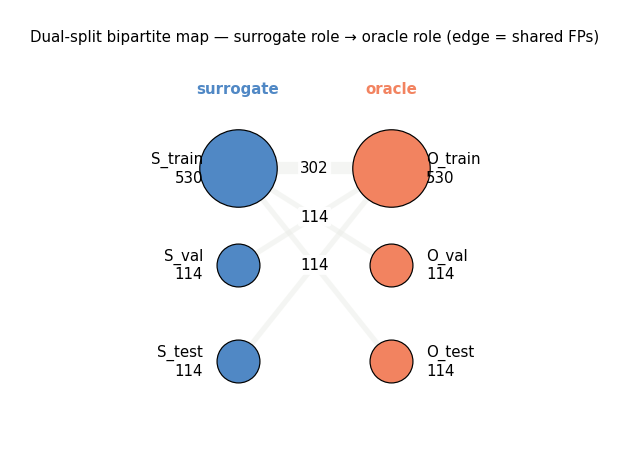

In [5]:
# Bipartite map of the dual split: surrogate roles (left) -> oracle roles (right); edge = # shared FPs
roles=["train","val","test"]
M={(s,o):int(((Srole==s)&(Orole==o)).sum()) for s in roles for o in roles}
Stot={s:int((Srole==s).sum()) for s in roles}; Otot={o:int((Orole==o).sum()) for o in roles}
print("surrogate-role -> oracle-role contingency:")
for s in roles: print(f"  S_{s:5s} -> "+", ".join(f"O_{o} {M[(s,o)]}" for o in roles))
yp={"train":2,"val":1,"test":0}; LX,RX=0.0,2.0; cmax=max(M.values())
fig,ax=plt.subplots(figsize=(6,6))
for s in roles:
    for o in roles:
        c=M[(s,o)]
        if c==0: continue
        ax.plot([LX,RX],[yp[s],yp[o]], lw=1.2+11*c/cmax, color=C.gray, alpha=0.5, zorder=1, solid_capstyle="round")
        ax.text(LX+0.5*(RX-LX), yp[s]+0.5*(yp[o]-yp[s]), str(c), ha="center", va="center", fontsize=15, zorder=3,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))
for s in roles:
    ax.scatter([LX],[yp[s]], s=700+10*Stot[s], color=C.aegean, ec="k", lw=1.2, zorder=2)
    ax.text(LX-0.45, yp[s], f"S_{s}\n{Stot[s]}", ha="right", va="center", fontsize=15)
for o in roles:
    ax.scatter([RX],[yp[o]], s=700+10*Otot[o], color=C.amber, ec="k", lw=1.2, zorder=2)
    ax.text(RX+0.45, yp[o], f"O_{o}\n{Otot[o]}", ha="left", va="center", fontsize=15)
ax.text(LX, 2.78, "surrogate", ha="center", fontsize=15, color=C.aegean, fontweight="bold")
ax.text(RX, 2.78, "oracle",    ha="center", fontsize=15, color=C.amber,  fontweight="bold")
ax.set_xlim(-1.6,3.6); ax.set_ylim(-0.7,3.15); ax.axis("off")
ax.set_title("Dual-split bipartite map — surrogate role → oracle role (edge = shared FPs)")
plt.tight_layout(); plt.show()

## 4-5. Visualize the curated splits

For each split (surrogate, then oracle): the ESM-2 embedding (t-SNE) colored by role, and the **ex_max**,
**em_max**, and **length** distributions as density histograms per role — to check the split is representative
across the spectral and length ranges.

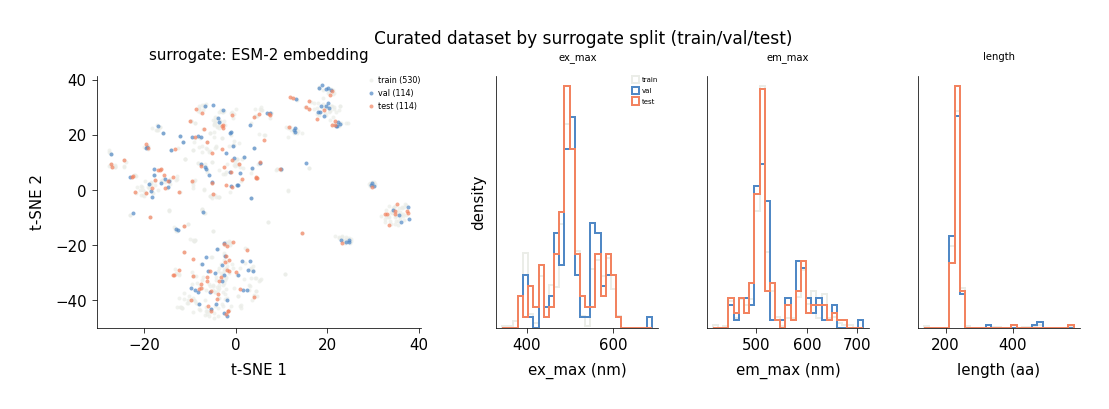

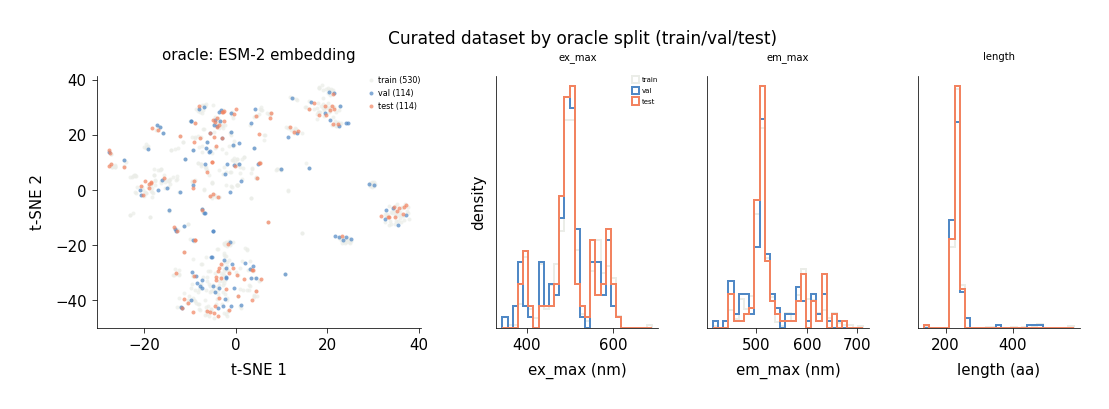

In [6]:
def viz_split(role, tag):
    fig=plt.figure(figsize=(15,4.6))
    ax0=fig.add_axes([0.05,0.12,0.30,0.76])
    for r in ["train","val","test"]:
        m=role==r; ax0.scatter(TSc[m,0],TSc[m,1],s=16,c=ROLECOL[r],alpha=0.7,label=f"{r} ({m.sum()})")
    ax0.set_xlabel("t-SNE 1"); ax0.set_ylabel("t-SNE 2"); ax0.set_title(f"{tag}: ESM-2 embedding"); ax0.legend(fontsize=8)
    for k,(arr,lab) in enumerate([(EXc,"ex_max (nm)"),(EMc,"em_max (nm)"),(LENc,"length (aa)")]):
        a=fig.add_axes([0.42+0.195*k,0.12,0.15,0.76])
        bins=np.linspace(arr.min(),arr.max(),30)
        for r in ["train","val","test"]:
            a.hist(arr[role==r],bins=bins,density=True,histtype="step",lw=2,color=ROLECOL[r],label=r)
        a.set_xlabel(lab); a.set_yticks([])
        if k==0: a.set_ylabel("density"); a.legend(fontsize=7)
        a.set_title(lab.split()[0],fontsize=10)
    plt.suptitle(f"Curated dataset by {tag} split (train/val/test)",y=1.02); plt.show()

viz_split(Srole, "surrogate")
viz_split(Orole, "oracle")

## Notes
- Outlier filter = **cofactor ∪ NN-4mer<0.10 ∪ name~(frFAST|nirFAST)**. The explicit FAST flag is needed because
  those two sit at NN≈0.72 (not isolated) and carry no cofactor tag, yet their peak is set by an exogenous fluorogen.
- Curated artifacts (`training_data/curated/`): `peaks.npy`, `sequences.fasta`, `peak_assignments.csv`
  (with `orig_index`), `keep_index.npy`, `dual_splits.csv`, `curate_meta.json`. Embeddings are reused from the
  full cache via `keep_index` (no re-embedding).
- Split logic mirrors `surrogate_oracle_peak_dual.ipynb` (seed 0, 70/15/15, coordinated S/O). The density
  histograms show val/test track the train distribution across ex_max, em_max and length for both splits.